In [ ]:
!pip -q install pytorch-tabular torchmetrics

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split, StratifiedKFold
#from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from tqdm.auto import tqdm

from pytorch_tabular import TabularModel
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
from pytorch_tabular.models.ft_transformer.config import FTTransformerConfig

import matplotlib.pyplot as plt

from pytorch_lightning.callbacks import Callback
import matplotlib.pyplot as plt



In [ ]:
# Compute MSE only for organ concentrations that are present in the dataset
class MaskedMeanSquaredErrorLoss(nn.Module):
    def __init__(self, epsilon_value: float = 1e-8):
        super().__init__()
        self.epsilon_value = epsilon_value

    def forward(self, predictions: torch.Tensor, ground_truth: torch.Tensor):
        valid_data_mask = ~torch.isnan(ground_truth)
        if valid_data_mask.sum() == 0:
            return torch.zeros((), device=predictions.device, dtype=predictions.dtype)

        differences = predictions[valid_data_mask] - ground_truth[valid_data_mask]
        return (differences * differences).mean()

# metric to compute MSE
def masked_mean_squared_error_metric(predictions: torch.Tensor, ground_truth: torch.Tensor):
    valid_data_mask = ~torch.isnan(ground_truth)
    if valid_data_mask.sum() == 0:
        return torch.tensor(0.0, device=predictions.device)

    differences = predictions[valid_data_mask] - ground_truth[valid_data_mask]
    return (differences * differences).mean()

In [ ]:
organ_concentration_dataframe = pd.read_csv("/content/dataset/OrganConcentrationTimelinesData.csv")

design_numeric_features = [
    "Size(TEM) (nm)",
    "Size(HD) (nm)",
    "Zeta Potential (mV)",
    "PDI"
]

design_categorical_features = [
    "Particle Type",
    "Core Material",
    "Targeting Strategy",
    #"NP ID",
    "Shape",
]

context_numeric_features = [
    "Tumor Size (cm3)",
    "Administration Dose (mg/kg)",
    "Time Point (h)",
    "Body weight (g)"
]

context_categorical_features = [
    "Tumor Cell"
]

target_concentration_columns = [
    "Tumor Concentration (%ID/g)",
    "Heart Concentration (%ID/g)",
    "Liver Concentration (%ID/g)",
    "Lung Concentration (%ID/g)",
    "Spleen Concentration (%ID/g)",
    "Kidney Concentration (%ID/g)",
]

In [ ]:
numeric_input_features = design_numeric_features + context_numeric_features
categorical_input_features = design_categorical_features + context_categorical_features

input_feature_columns = (
    numeric_input_features +
    categorical_input_features
)

In [ ]:
# function to extract tumor location
def extract_tumor_location(cell_string):
    if pd.isna(cell_string) or str(cell_string).strip() == "UNKNOWN":
        return "UNKNOWN"

    cell_string = str(cell_string).strip()

    # check if the string contains " in "
    if " in " in cell_string:
        # split from the right side and grab the location
        location = cell_string.rsplit(" in ", 1)[-1]
        return location.strip().capitalize()

    # if " in " is missing
    return cell_string.capitalize()

organ_concentration_dataframe["Tumor Cell"] = organ_concentration_dataframe["Tumor Cell"].apply(extract_tumor_location)

print("New aggregated tumor cell:")
print(organ_concentration_dataframe["Tumor Cell"].value_counts())

New aggregated tumor cell:
Tumor Cell
Breast      715
Liver       406
Skin        200
Colon       197
Cervix      159
Lung        135
Brain       113
Ovary        90
Sarcoma      87
Prostate     59
Pancreas     53
Glioma       39
Stomach      32
Lymphoma     30
Kidney        9
Other         8
Name: count, dtype: int64


In [ ]:
rare_tumor_categories = ["Kidney", "Other"]

def group_rare_tumors(tumor_name):
    if tumor_name in rare_tumor_categories:
        return "Other"
    return tumor_name

organ_concentration_dataframe["Tumor Cell"] = organ_concentration_dataframe["Tumor Cell"].apply(group_rare_tumors)

print("\nFinal Tumor Cell counts after grouping rare types:")
print(organ_concentration_dataframe["Tumor Cell"].value_counts())


Final Tumor Cell counts after grouping rare types:
Tumor Cell
Breast      715
Liver       406
Skin        200
Colon       197
Cervix      159
Lung        135
Brain       113
Ovary        90
Sarcoma      87
Prostate     59
Pancreas     53
Glioma       39
Stomach      32
Lymphoma     30
Other        17
Name: count, dtype: int64


In [ ]:
# handle non-numeric values in numeric columns (find mean)
def convert_string_ranges_to_numeric_means(value):
    if pd.isna(value):
        return np.nan
    string_value = str(value).strip()
    if string_value == "":
        return np.nan

    if "-" in string_value:
        split_parts = string_value.split("-")
        if len(split_parts) != 2:
            return np.nan
        try:
            lower_bound = float(split_parts[0].strip())
            upper_bound_string = split_parts[1].strip()
            if upper_bound_string.lower() == "infinity":
                return lower_bound
            upper_bound = float(upper_bound_string)
            return (lower_bound + upper_bound) / 2.0
        except Exception:
            return np.nan

    try:
        return float(string_value)
    except Exception:
        return np.nan

In [ ]:
# apply range conversions
features_with_string_ranges = ["Tumor Size (cm3)", "Body weight (g)"]
for feature_name in features_with_string_ranges:
    organ_concentration_dataframe[feature_name] = organ_concentration_dataframe[feature_name].apply(convert_string_ranges_to_numeric_means)

In [ ]:
# coerce numerics and targets to float
for feature_name in numeric_input_features + target_concentration_columns:
    organ_concentration_dataframe[feature_name] = pd.to_numeric(organ_concentration_dataframe[feature_name], errors="coerce")

In [ ]:
# handle categorical missing values
for feature_name in categorical_input_features:
    organ_concentration_dataframe[feature_name] = organ_concentration_dataframe[feature_name].fillna("UNKNOWN").astype(str)

# Iterative Imputation for missing numeric inputs
numeric_features_imputer = IterativeImputer(max_iter=10, random_state=42)
organ_concentration_dataframe[numeric_input_features] = numeric_features_imputer.fit_transform(organ_concentration_dataframe[numeric_input_features])

In [ ]:
# log-transform skewed numerical inputs
features_to_log_transform = ["Administration Dose (mg/kg)", "Time Point (h)"]
for feature_name in features_to_log_transform:
    organ_concentration_dataframe[feature_name] = np.log1p(organ_concentration_dataframe[feature_name].clip(lower=0))

In [ ]:
# log-transform targets to equalize loss across organs
for target_name in target_concentration_columns:
    clipped_target = organ_concentration_dataframe[target_name].clip(lower=0)
    organ_concentration_dataframe[target_name] = np.log1p(clipped_target)

In [ ]:
# data splitting (based on research paper)
#reference_group_column = "Reference"
#dataset_reference_groups = organ_concentration_dataframe[reference_group_column].fillna("UNKNOWN").astype(str)

#dataset_group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
#training_validation_indices, testing_indices = next(dataset_group_splitter.split(organ_concentration_dataframe, groups=dataset_reference_groups))

#training_validation_dataframe = organ_concentration_dataframe.iloc[training_validation_indices].copy()
#testing_dataframe = organ_concentration_dataframe.iloc[testing_indices].copy()

In [ ]:
# model and trainer configurations
tabular_data_configuration = DataConfig(
    target=target_concentration_columns,
    continuous_cols=numeric_input_features,
    categorical_cols=categorical_input_features,
)

model_optimizer_configuration = OptimizerConfig(
    optimizer="AdamW",
    optimizer_params={"weight_decay": 1e-4},
)
#model_optimizer_configuration = OptimizerConfig(
#    optimizer="AdamW",
#    optimizer_params={"weight_decay": 1e-3},
#    lr_scheduler="ReduceLROnPlateau",
#    lr_scheduler_params={
#        "mode": "min",
#        "factor": 0.5,
#        "patience": 3,
#    },
#)
transformer_model_configuration = FTTransformerConfig(
    task="regression",
    num_heads=8,
    num_attn_blocks=4,
    attn_dropout=0.1,
    add_norm_dropout=0.1,
    ff_dropout=0.1,
    input_embed_dim=32,
    share_embedding=False,
    batch_norm_continuous_input=True,
    learning_rate=1e-3,
    loss=None,
    metrics=["masked_mse_metric"],
    metrics_params=[{}],
)

cross_validation_trainer_configuration = TrainerConfig(
    batch_size=256,
    max_epochs=200,
    accelerator="auto",
    early_stopping="valid_loss",
    early_stopping_patience=8,
    progress_bar="rich",
    trainer_kwargs={"log_every_n_steps": 1}
)

In [ ]:


class LossHistoryTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.valid_losses = []

    def on_validation_epoch_end(self, trainer, pl_module):
        # PyTorch Lightning stores the latest metrics in trainer.callback_metrics
        metrics = trainer.callback_metrics

        if "train_loss" in metrics and "valid_loss" in metrics:
            self.train_losses.append(metrics["train_loss"].item())
            self.valid_losses.append(metrics["valid_loss"].item())

In [ ]:
# data splitting (stratified split)

stratification_feature_name = "Tumor Cell"

training_validation_dataframe, testing_dataframe = train_test_split(
    organ_concentration_dataframe,
    test_size=0.20,
    random_state=42,
    stratify=organ_concentration_dataframe[stratification_feature_name]
)
print("Train+Val rows:", len(training_validation_dataframe), " Test rows:", len(testing_dataframe))

Train+Val rows: 1865  Test rows: 467


In [ ]:
# plotting the Learning Curves
def plot_loss_curves(history_tracker, file_name):
    plt.figure(figsize=(10, 6))
    plt.plot(history_tracker.train_losses, label='Training Loss', color='blue', linewidth=2)
    plt.plot(history_tracker.valid_losses, label='Validation Loss', color='red', linewidth=2)

    plt.xlabel('Epochs')
    plt.ylabel('Masked MSE Loss')
    plt.title('DNN Training and Validation Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # save and show the plot
    plt.savefig("model_logs/" + file_name +".png")
    plt.show()

Cross-Validation Folds:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-02 04:17:02,017 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-04-02 04:17:02,024 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-02 04:17:02,027 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
2026-04-02 04:17:02,042 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-02 04:17:02,058 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Exp

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ MaskedMeanSquaredErrorLoss │      0 │ train │     0 │
│ 1 │ _backbone        │ FTTransformerBackbone      │  180 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer           │  3.8 K │ train │     0 │
│ 3 │ _head            │ LinearHead                 │    198 │ train │     0 │
└───┴──────────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 184 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 184 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

2026-04-02 04:17:15,563 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-02 04:17:15,563 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


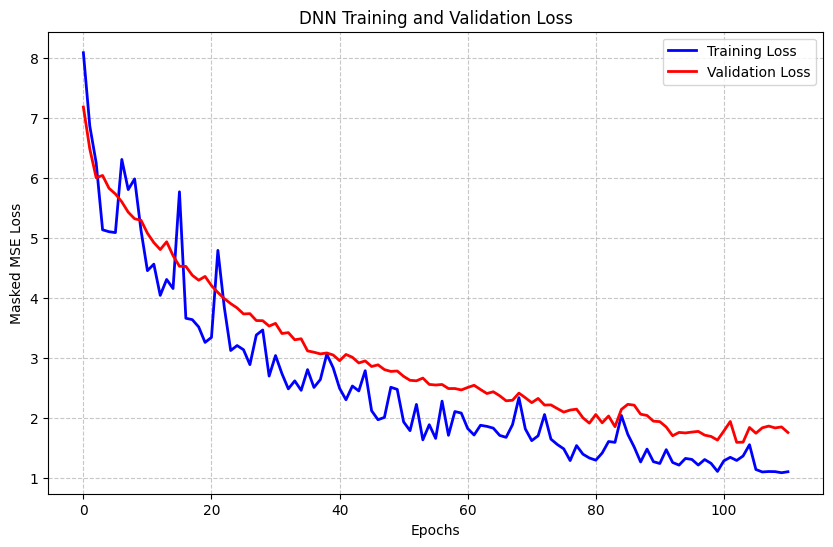

2026-04-02 04:17:15,709 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-04-02 04:17:15,716 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-02 04:17:15,718 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
2026-04-02 04:17:15,733 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-02 04:17:15,749 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Exp


Fold 1 Validation MAE (%ID/g):
  * Tumor Concentration (%ID/g): 4.0381
  * Heart Concentration (%ID/g): 2.3282
  * Liver Concentration (%ID/g): 8.2832
  * Lung Concentration (%ID/g): 5.2245
  * Spleen Concentration (%ID/g): 26.0370
  * Kidney Concentration (%ID/g): 3.4923


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ MaskedMeanSquaredErrorLoss │      0 │ train │     0 │
│ 1 │ _backbone        │ FTTransformerBackbone      │  180 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer           │  3.8 K │ train │     0 │
│ 3 │ _head            │ LinearHead                 │    198 │ train │     0 │
└───┴──────────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 184 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 184 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

2026-04-02 04:17:32,205 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-02 04:17:32,205 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


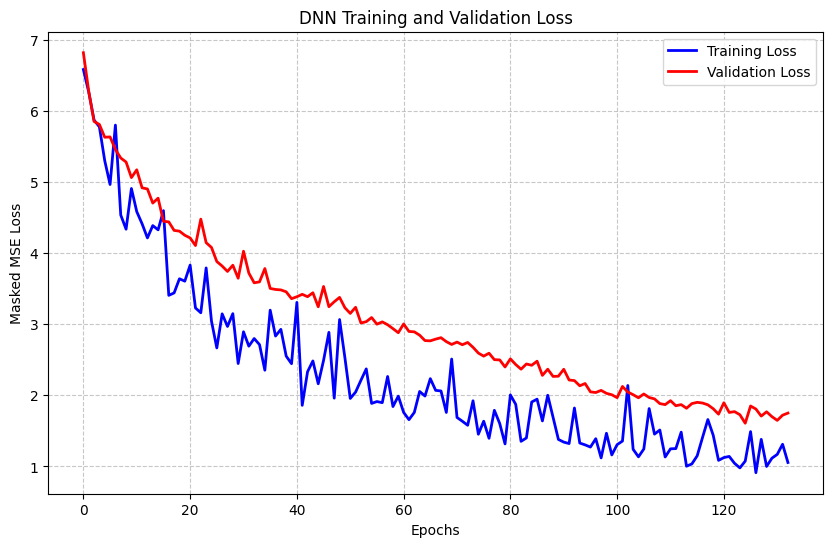

2026-04-02 04:17:32,355 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-04-02 04:17:32,362 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-02 04:17:32,364 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
2026-04-02 04:17:32,379 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-02 04:17:32,395 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Exp


Fold 2 Validation MAE (%ID/g):
  * Tumor Concentration (%ID/g): 4.9059
  * Heart Concentration (%ID/g): 4.2044
  * Liver Concentration (%ID/g): 8.8336
  * Lung Concentration (%ID/g): 4.6419
  * Spleen Concentration (%ID/g): 27.6301
  * Kidney Concentration (%ID/g): 3.9001


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ MaskedMeanSquaredErrorLoss │      0 │ train │     0 │
│ 1 │ _backbone        │ FTTransformerBackbone      │  180 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer           │  3.8 K │ train │     0 │
│ 3 │ _head            │ LinearHead                 │    198 │ train │     0 │
└───┴──────────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 184 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 184 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

2026-04-02 04:17:48,216 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-02 04:17:48,216 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


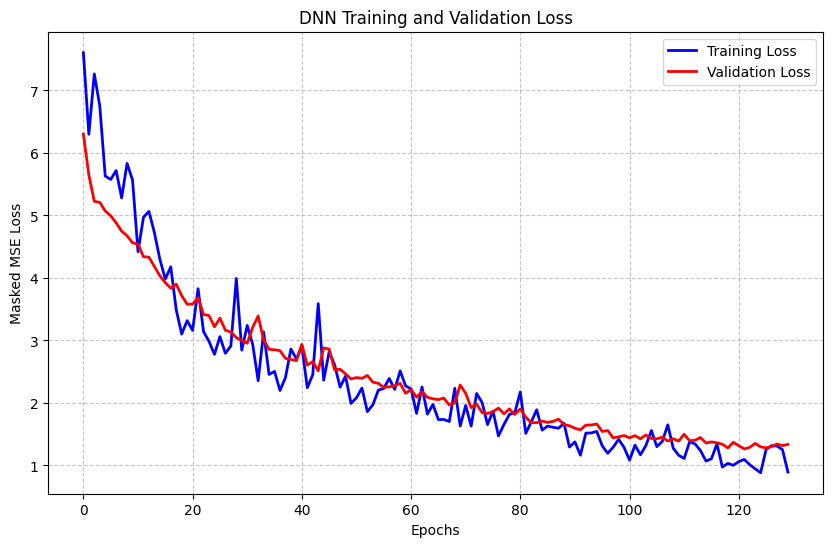

2026-04-02 04:17:48,362 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-04-02 04:17:48,369 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-02 04:17:48,371 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
2026-04-02 04:17:48,385 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-02 04:17:48,401 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Exp


Fold 3 Validation MAE (%ID/g):
  * Tumor Concentration (%ID/g): 5.2565
  * Heart Concentration (%ID/g): 2.2283
  * Liver Concentration (%ID/g): 8.6408
  * Lung Concentration (%ID/g): 3.3186
  * Spleen Concentration (%ID/g): 9.0418
  * Kidney Concentration (%ID/g): 2.6576


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ MaskedMeanSquaredErrorLoss │      0 │ train │     0 │
│ 1 │ _backbone        │ FTTransformerBackbone      │  180 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer           │  3.8 K │ train │     0 │
│ 3 │ _head            │ LinearHead                 │    198 │ train │     0 │
└───┴──────────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 184 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 184 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

2026-04-02 04:18:02,729 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-02 04:18:02,729 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


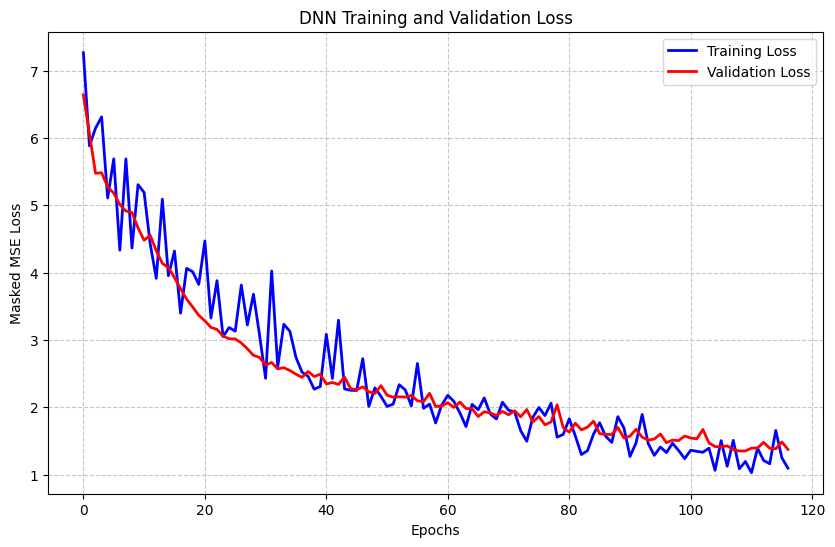

2026-04-02 04:18:02,875 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-04-02 04:18:02,882 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-02 04:18:02,884 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
2026-04-02 04:18:02,898 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-02 04:18:02,914 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Exp


Fold 4 Validation MAE (%ID/g):
  * Tumor Concentration (%ID/g): 4.3920
  * Heart Concentration (%ID/g): 1.5940
  * Liver Concentration (%ID/g): 6.8416
  * Lung Concentration (%ID/g): 3.7080
  * Spleen Concentration (%ID/g): 11.6026
  * Kidney Concentration (%ID/g): 2.4744


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ MaskedMeanSquaredErrorLoss │      0 │ train │     0 │
│ 1 │ _backbone        │ FTTransformerBackbone      │  180 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer           │  3.8 K │ train │     0 │
│ 3 │ _head            │ LinearHead                 │    198 │ train │     0 │
└───┴──────────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 184 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 184 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

2026-04-02 04:18:14,879 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-02 04:18:14,879 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


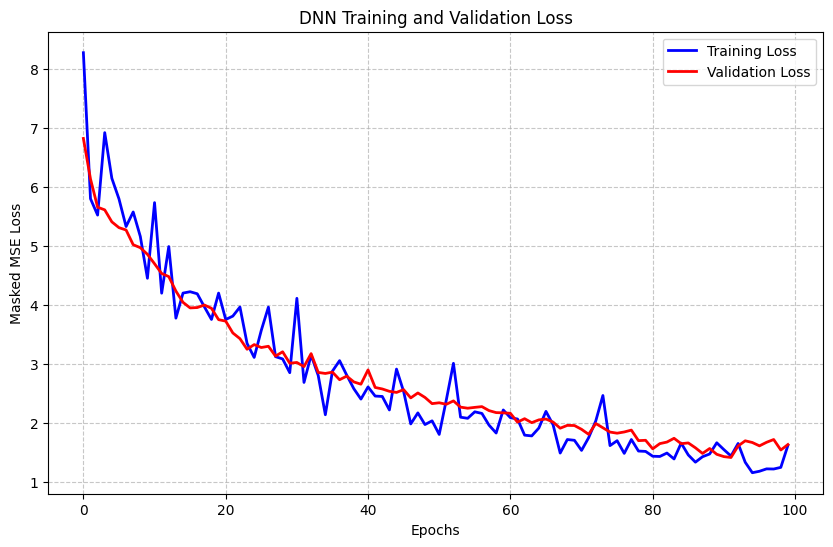


Fold 5 Validation MAE (%ID/g):
  * Tumor Concentration (%ID/g): 4.6901
  * Heart Concentration (%ID/g): 2.6113
  * Liver Concentration (%ID/g): 9.8581
  * Lung Concentration (%ID/g): 4.0481
  * Spleen Concentration (%ID/g): 9.7193
  * Kidney Concentration (%ID/g): 2.9731


In [ ]:
# cross-validation training
number_of_folds = 5
#cross_validation_kfold = GroupKFold(n_splits=number_of_folds)
#cross_validation_kfold = KFold(n_splits=number_of_folds, shuffle=True, random_state=42)

stratified_kfold_splitter = StratifiedKFold(
    n_splits=number_of_folds,
    shuffle=True,
    random_state=42
)

#training_validation_groups = training_validation_dataframe[reference_group_column].fillna("UNKNOWN").astype(str)

stratification_labels_for_cross_validation = training_validation_dataframe[stratification_feature_name]

predicted_column_names = [f"{target}_prediction" for target in target_concentration_columns]


#cross_validation_splits = list(cross_validation_kfold.split(training_validation_dataframe, groups=training_validation_groups))


cross_validation_splits = stratified_kfold_splitter.split(
    X=training_validation_dataframe,
    y=stratification_labels_for_cross_validation
)

for fold_index, (fold_training_indices, fold_validation_indices) in tqdm(enumerate(cross_validation_splits, start=1), total=number_of_folds, desc="Cross-Validation Folds"):

    fold_training_dataframe = training_validation_dataframe.iloc[fold_training_indices].copy()
    fold_validation_dataframe = training_validation_dataframe.iloc[fold_validation_indices].copy()

    history_tracker = LossHistoryTracker()

    # target normalization
    # calculate mean and std from the training fold
    target_means = fold_training_dataframe[target_concentration_columns].mean()
    target_stds = fold_training_dataframe[target_concentration_columns].std()

    # scale both training and validation folds
    fold_training_dataframe[target_concentration_columns] = (fold_training_dataframe[target_concentration_columns] - target_means) / target_stds
    fold_validation_dataframe[target_concentration_columns] = (fold_validation_dataframe[target_concentration_columns] - target_means) / target_stds

    fold_tabular_model = TabularModel(
        data_config=tabular_data_configuration,
        model_config=transformer_model_configuration,
        optimizer_config=model_optimizer_configuration,
        trainer_config=cross_validation_trainer_configuration,
    )

    fold_tabular_model.fit(
        train=fold_training_dataframe,
        validation=fold_validation_dataframe,
        loss=MaskedMeanSquaredErrorLoss(),
        metrics=[masked_mean_squared_error_metric],
        metrics_prob_inputs=[False],
        callbacks=[history_tracker]
    )

    # fold evaluation
    fold_validation_predictions_dataframe = fold_tabular_model.predict(fold_validation_dataframe)
    fold_predicted_values = fold_validation_predictions_dataframe[predicted_column_names].to_numpy(dtype=np.float32)
    fold_ground_truth_values = fold_validation_dataframe[target_concentration_columns].to_numpy(dtype=np.float32)

    fold_valid_data_mask = ~np.isnan(fold_ground_truth_values)
    fold_clean_ground_truth = np.nan_to_num(fold_ground_truth_values, nan=0.0)

    # reverse target normalization

    np_target_stds = target_stds.to_numpy(dtype=np.float32)
    np_target_means = target_means.to_numpy(dtype=np.float32)

    fold_predicted_values = (fold_predicted_values * np_target_stds) + np_target_means
    fold_clean_ground_truth = (fold_clean_ground_truth * np_target_stds) + np_target_means

    # inverse log transform
    fold_predicted_values_raw = np.expm1(fold_predicted_values)
    fold_clean_ground_truth_raw = np.expm1(fold_clean_ground_truth)

    fold_absolute_error = np.abs(fold_predicted_values_raw - fold_clean_ground_truth_raw) * fold_valid_data_mask
    fold_denominator = np.maximum(fold_valid_data_mask.sum(axis=0), 1e-8)
    fold_mean_absolute_error = fold_absolute_error.sum(axis=0) / fold_denominator

    # plotting the learning curves

    plot_loss_curves(history_tracker, "dnn_learning_curve_fold_" + str(fold_index))

    print(f"\nFold {fold_index} Validation MAE (%ID/g):")
    for organ_name, mae_value in zip(target_concentration_columns, fold_mean_absolute_error):
        print(f"  * {organ_name}: {mae_value:.4f}")

2026-04-02 04:18:15,026 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-04-02 04:18:15,036 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-02 04:18:15,039 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
2026-04-02 04:18:15,055 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-02 04:18:15,071 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Exp


Training Final Model on Full Train/Validation Set...


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ custom_loss      │ MaskedMeanSquaredErrorLoss │      0 │ train │     0 │
│ 1 │ _backbone        │ FTTransformerBackbone      │  180 K │ train │     0 │
│ 2 │ _embedding_layer │ Embedding2dLayer           │  3.8 K │ train │     0 │
│ 3 │ _head            │ LinearHead                 │    198 │ train │     0 │
└───┴──────────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 184 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 184 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 96                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


2026-04-02 04:18:39,044 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-02 04:18:39,044 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


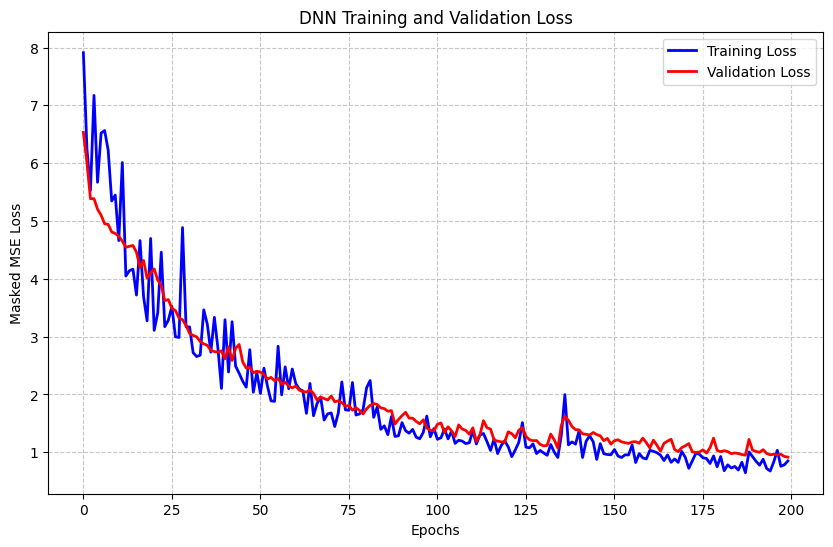

In [ ]:
# final model training and testing
final_training_trainer_configuration = TrainerConfig(
    batch_size=256,
    max_epochs=200,
    accelerator="auto",
    early_stopping=None,
    progress_bar="rich",
    trainer_kwargs={"log_every_n_steps": 1}
)

final_tabular_model = TabularModel(
    data_config=tabular_data_configuration,
    model_config=transformer_model_configuration,
    optimizer_config=model_optimizer_configuration,
    trainer_config=final_training_trainer_configuration,
)

history_tracker = LossHistoryTracker()

# target normalization
final_target_means = training_validation_dataframe[target_concentration_columns].mean()
final_target_stds = training_validation_dataframe[target_concentration_columns].std()

training_validation_dataframe[target_concentration_columns] = (training_validation_dataframe[target_concentration_columns] - final_target_means) / final_target_stds
testing_dataframe[target_concentration_columns] = (testing_dataframe[target_concentration_columns] - final_target_means) / final_target_stds

print("\nTraining Final Model on Full Train/Validation Set...")
final_tabular_model.fit(
    train=training_validation_dataframe,
    validation=None,
    loss=MaskedMeanSquaredErrorLoss(),
    metrics=[masked_mean_squared_error_metric],
    metrics_prob_inputs=[False],
    callbacks=[history_tracker]
)

plot_loss_curves(history_tracker, "dnn_learning_curve_final")

In [ ]:
# test set evaluation

testing_predictions_dataframe = final_tabular_model.predict(testing_dataframe)
testing_predicted_values = testing_predictions_dataframe[predicted_column_names].to_numpy(dtype=np.float32)

testing_ground_truth_values = testing_dataframe[target_concentration_columns].to_numpy(dtype=np.float32)
testing_valid_data_mask = ~np.isnan(testing_ground_truth_values)
testing_clean_ground_truth_log = np.nan_to_num(testing_ground_truth_values, nan=0.0)

# reverse target normalization
np_final_stds = final_target_stds.to_numpy(dtype=np.float32)
np_final_means = final_target_means.to_numpy(dtype=np.float32)
testing_predicted_values = (testing_predicted_values * np_final_stds) + np_final_means
testing_clean_ground_truth_log = (testing_clean_ground_truth_log * np_final_stds) + np_final_means

# inverse log transform for testing data
testing_predicted_values_raw = np.expm1(testing_predicted_values)
testing_clean_ground_truth_raw = np.expm1(testing_clean_ground_truth_log)

testing_absolute_error = np.abs(testing_predicted_values_raw - testing_clean_ground_truth_raw) * testing_valid_data_mask
testing_squared_error = ((testing_predicted_values_raw - testing_clean_ground_truth_raw) ** 2) * testing_valid_data_mask
testing_denominator = np.maximum(testing_valid_data_mask.sum(axis=0), 1e-8)

testing_mean_absolute_error = testing_absolute_error.sum(axis=0) / testing_denominator
testing_root_mean_squared_error = np.sqrt(testing_squared_error.sum(axis=0) / testing_denominator)

# calculate Residual Sum of Squares
testing_residual_sum_of_squares = testing_squared_error.sum(axis=0)

# calculate the mean of the true values for each organ, considering only valid (non-NaN) entries
testing_sum_valid_ground_truth = (testing_clean_ground_truth_raw * testing_valid_data_mask).sum(axis=0)
testing_mean_valid_ground_truth = testing_sum_valid_ground_truth / testing_denominator

# calculate total sum of squares
testing_differences_from_mean = (testing_clean_ground_truth_raw - testing_mean_valid_ground_truth) * testing_valid_data_mask
testing_total_sum_of_squares = (testing_differences_from_mean ** 2).sum(axis=0)

# calculate R-squared score (minimum value of 1e-8 is used for the denominator to prevent division by zero)
testing_r_squared_scores = 1.0 - (testing_residual_sum_of_squares / np.maximum(testing_total_sum_of_squares, 1e-8))

print("\nFINAL TEST EVALUATION (%ID/g):")
for target_organ_name, mean_absolute_error_value, root_mean_squared_error_value, r_squared_value in zip(target_concentration_columns, testing_mean_absolute_error, testing_root_mean_squared_error, testing_r_squared_scores):
    print(f"  * {target_organ_name} - MAE: {mean_absolute_error_value:.4f} | RMSE: {root_mean_squared_error_value:.4f} | R2: {r_squared_value:.4f}")

print(f"\nFINAL TEST MAE per organ (%ID/g):")
for organ_name, mae_value in zip(target_concentration_columns, testing_mean_absolute_error):
    print(f"  * {organ_name}: {mae_value:.4f}")
print(f"\nFINAL TEST RMSE per organ (%ID/g):")
for organ_name, rmse_value in zip(target_concentration_columns, testing_root_mean_squared_error):
    print(f"  * {organ_name}: {rmse_value:.4f}")
print(f"\nFINAL TEST R2 per organ (%ID/g):")
for organ_name, r2_value in zip(target_concentration_columns, testing_r_squared_scores):
    print(f"  * {organ_name}: {r2_value:.4f}")



FINAL TEST EVALUATION (%ID/g):
  * Tumor Concentration (%ID/g) - MAE: 3.9591 | RMSE: 13.2515 | R2: 0.6755
  * Heart Concentration (%ID/g) - MAE: 1.8297 | RMSE: 6.2348 | R2: 0.8256
  * Liver Concentration (%ID/g) - MAE: 6.9411 | RMSE: 15.6849 | R2: 0.7729
  * Lung Concentration (%ID/g) - MAE: 3.3887 | RMSE: 11.2484 | R2: 0.6615
  * Spleen Concentration (%ID/g) - MAE: 10.2577 | RMSE: 30.2426 | R2: 0.7725
  * Kidney Concentration (%ID/g) - MAE: 2.5253 | RMSE: 7.7121 | R2: 0.7714

FINAL TEST MAE per organ (%ID/g):
  * Tumor Concentration (%ID/g): 3.9591
  * Heart Concentration (%ID/g): 1.8297
  * Liver Concentration (%ID/g): 6.9411
  * Lung Concentration (%ID/g): 3.3887
  * Spleen Concentration (%ID/g): 10.2577
  * Kidney Concentration (%ID/g): 2.5253

FINAL TEST RMSE per organ (%ID/g):
  * Tumor Concentration (%ID/g): 13.2515
  * Heart Concentration (%ID/g): 6.2348
  * Liver Concentration (%ID/g): 15.6849
  * Lung Concentration (%ID/g): 11.2484
  * Spleen Concentration (%ID/g): 30.2426
 

In [ ]:
# save model
model_save_path = "ft_transformer_nanomedicine_model"
final_tabular_model.save_model(model_save_path)
print(f"\nFinal model saved")

INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.



Final model saved


In [ ]:
def plot_predicted_versus_true_concentrations(
    true_values_array,
    predicted_values_array,
    valid_data_mask_array,
    organ_column_names
):

    figure, subplot_axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    subplot_axes = subplot_axes.flatten()

    for organ_index, target_organ_name in enumerate(organ_column_names):
        current_axis = subplot_axes[organ_index]

        # xxtract only the non-NaN values for this specific organ
        organ_valid_mask = valid_data_mask_array[:, organ_index]
        organ_true_values = true_values_array[organ_valid_mask, organ_index]
        organ_predicted_values = predicted_values_array[organ_valid_mask, organ_index]

        # plot the data points
        current_axis.scatter(
            organ_true_values,
            organ_predicted_values,
            alpha=0.6,
            color='royalblue',
            edgecolor='black',
            label='Predictions'
        )

        # plot the ideal y=x reference line
        if len(organ_true_values) > 0:
            minimum_value = min(organ_true_values.min(), organ_predicted_values.min())
            maximum_value = max(organ_true_values.max(), organ_predicted_values.max())
            current_axis.plot(
                [minimum_value, maximum_value],
                [minimum_value, maximum_value],
                color='red',
                linestyle='--',
                linewidth=2,
                label='Ideal (True = Predicted)'
            )

        clean_title = target_organ_name.replace(" Concentration (%ID/g)", "")
        current_axis.set_title(f'{clean_title} Biodistribution', fontsize=14, fontweight='bold')
        current_axis.set_xlabel('True Concentration (%ID/g)', fontsize=12)
        current_axis.set_ylabel('Predicted Concentration (%ID/g)', fontsize=12)
        current_axis.legend(loc='upper left')
        current_axis.grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout()
    plot_filename = "predicted_vs_true_concentrations.png"
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nScatter plots successfully saved to {plot_filename}")

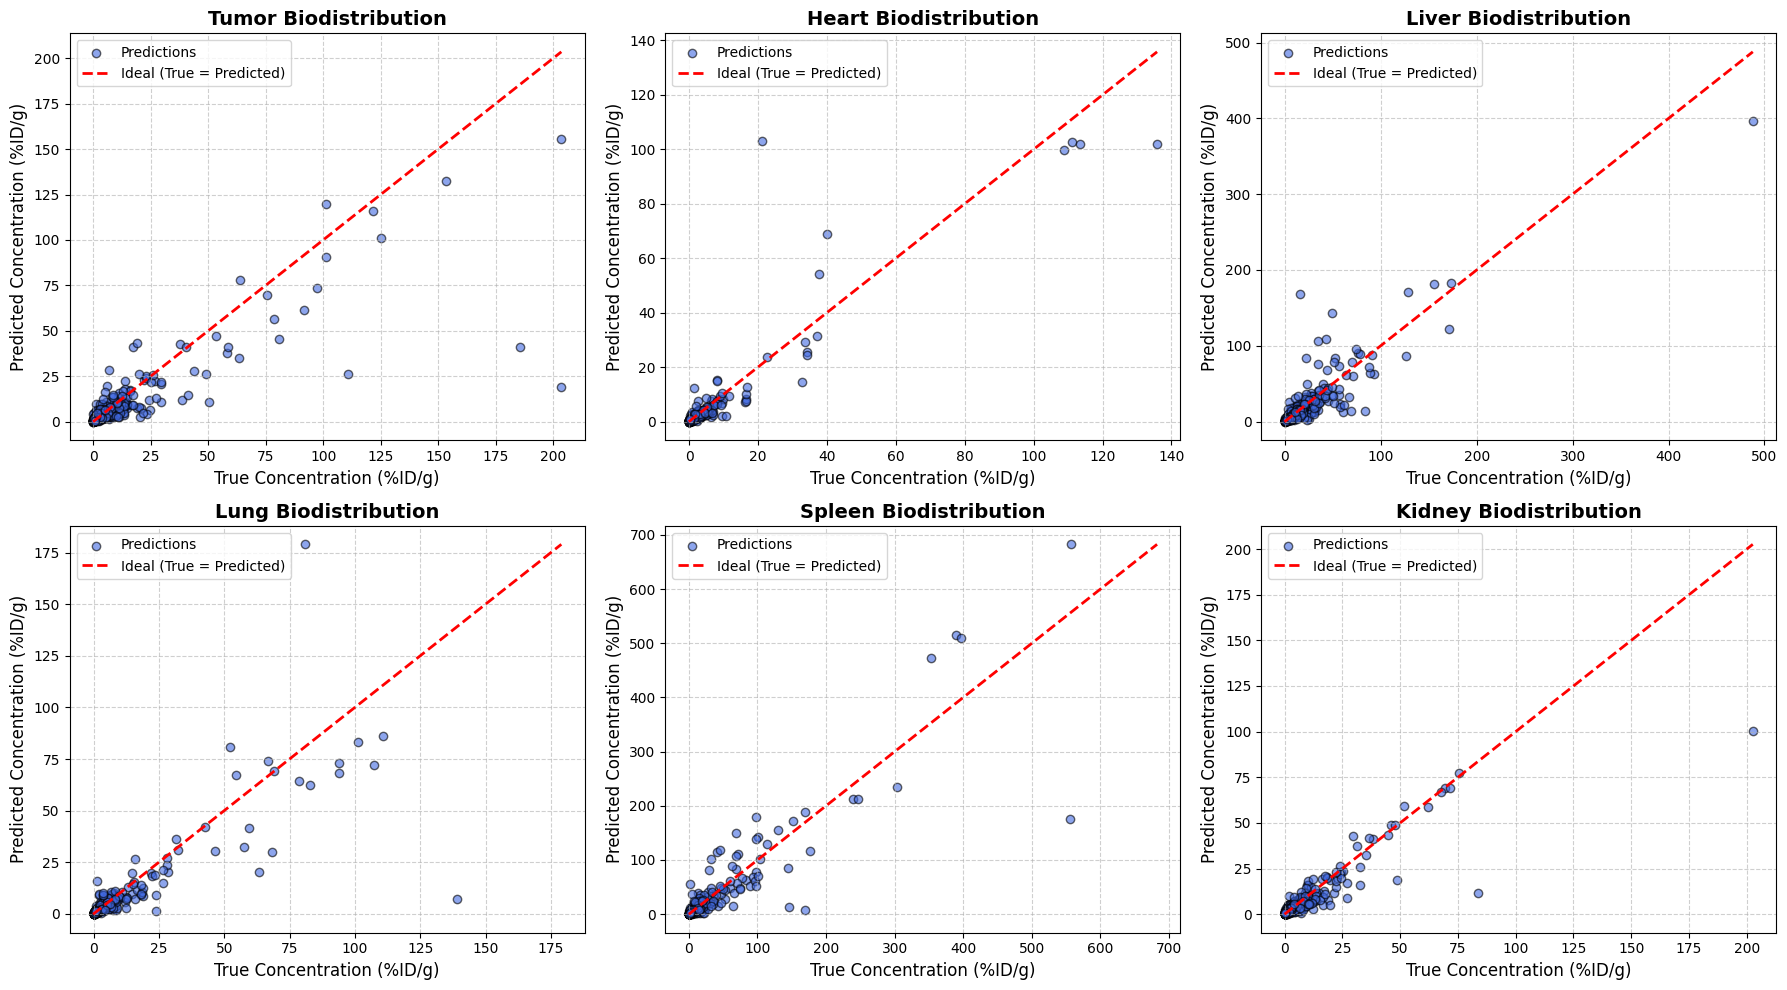


Scatter plots successfully saved to predicted_vs_true_concentrations.png


In [ ]:
plot_predicted_versus_true_concentrations(
    true_values_array=testing_clean_ground_truth_raw,
    predicted_values_array=testing_predicted_values_raw,
    valid_data_mask_array=testing_valid_data_mask,
    organ_column_names=target_concentration_columns
)